# Tokenizacion y Analisis de Sentimiento

### De caracteres a palabras

En el notebook anterior trabajamos letra por letra. Para la mayoria de las tareas de NLP es mas comun trabajar con unidades mas grandes: palabras, o pedazos de palabras. A este proceso de cortar el texto en unidades se lo llama **tokenizacion**, y cada unidad resultante es un **token**.

Antes de entrenar el clasificador, vamos a entender -- programandolo a mano en una version chiquita -- una de las tecnicas de tokenizacion mas usadas hoy en dia: **BPE (Byte Pair Encoding)**.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 1. Como funciona BPE, a mano

La idea de BPE es simple: empezar con el texto separado en caracteres individuales, y en cada paso, fusionar el par de simbolos adyacentes mas frecuente en todo el corpus, convirtiendolo en un nuevo simbolo. Se repite este proceso muchas veces, y asi se van formando pedazos de palabras cada vez mas largos (los mas frecuentes primero).

Vamos a probarlo sobre un corpus de juguete: cuatro palabras, cada una con la cantidad de veces que aparece.

In [11]:
# creamos un dictionary que combina caracteres individuales de la palabra y cuentas veces aparece en el texto
palabras = {
    ("l", "o", "w", "</w>"): 5,
    ("l", "o", "w", "e", "r", "</w>"): 2,
    ("n", "e", "w", "e", "s", "t", "</w>"): 6,
    ("w", "i", "d", "e", "s", "t", "</w>"): 3,
}

print(palabras.items())

dict_items([(('l', 'o', 'w', '</w>'), 5), (('l', 'o', 'w', 'e', 'r', '</w>'), 2), (('n', 'e', 'w', 'e', 's', 't', '</w>'), 6), (('w', 'i', 'd', 'e', 's', 't', '</w>'), 3)])



<br>En BPE queremos saber **qué pares de símbolos aparecen juntos con mayor frecuencia** en todo el corpus.  
<br>
Creamos una funcion que recorre todas las palabras y cuenta cuántas veces aparece cada uno de estos pares.

In [12]:
def contar_pares(palabras):
    pares = {}  # diccionario para guardar cada par y su frecuencia
    for palabra, frecuencia in palabras.items():  # Recorremos cada palabra junto con su frecuencia
        for i in range(len(palabra) - 1):  # Recorremos las posiciones donde podemos formar un par

            par = (palabra[i], palabra[i + 1])  # Creamos un par con dos simbolos consecutivos
            pares[par] = pares.get(par, 0) + frecuencia  # Sumamos la frecuencia de la palabra completa al par

    return pares  # Devolvemos el diccionario con todos los pares y sus frecuencias

# prueba
contar_pares(palabras)

{('l', 'o'): 7,
 ('o', 'w'): 7,
 ('w', '</w>'): 5,
 ('w', 'e'): 8,
 ('e', 'r'): 2,
 ('r', '</w>'): 2,
 ('n', 'e'): 6,
 ('e', 'w'): 6,
 ('e', 's'): 9,
 ('s', 't'): 9,
 ('t', '</w>'): 9,
 ('w', 'i'): 3,
 ('i', 'd'): 3,
 ('d', 'e'): 3}

`("l", "o")` aparece en:  


```
"low"   → 5 times
"lower" → 2 times
```
Entonces, aparece en el corpus completo

`("l", "o") → 5 + 2 = 7 occurrences`

Después, elegimos el **par más frecuente**.

Por ejemplo, supongamos que el par más frecuente es:

`("l", "o")` y tenemos la palabra representado como: `("l", "o", "w", "</w>")`  
BPE fusiona "l" y "o" y los convierte en un solo símbolo: `("lo", "w", "</w>")`

In [13]:
# Fusiona un par de simbolos en un solo simbolo dentro de todas las palabras
def fusionar_par(par, palabras):

    a, b = par  # Separamos el par en sus dos simbolos
    nuevas_palabras = {}  # Creamos un diccionario para guardar las palabras despues de la fusion

    for palabra, frecuencia in palabras.items():  # Recorremos cada palabra y su frecuencia
        nueva_palabra = []  # Creamos una lista para construir la nueva representacion de la palabra
        i = 0  # Empezamos a recorrer la palabra desde la primera posicion

        while i < len(palabra):  # Seguimos recorriendo mientras no lleguemos al final
            if i < len(palabra) - 1 and palabra[i] == a and palabra[i + 1] == b:  # Comprobamos si encontramos el par que queremos fusionar
                nueva_palabra.append(a + b)  # Fusionamos los dos simbolos y los guardamos como uno solo
                i += 2  # Avanzamos dos posiciones porque ya procesamos los dos simbolos

            else:
                nueva_palabra.append(palabra[i])  # Si no encontramos el par, mantenemos el simbolo original
                i += 1  # Avanzamos una posicion

        nuevas_palabras[tuple(nueva_palabra)] = frecuencia  # Guardamos la nueva palabra manteniendo su frecuencia

    return nuevas_palabras  # Devolvemos el diccionario con las palabras actualizadas


### Prueba
par_prueba = ("l", "o")
fusionar_par(par_prueba, palabras)


{('lo', 'w', '</w>'): 5,
 ('lo', 'w', 'e', 'r', '</w>'): 2,
 ('n', 'e', 'w', 'e', 's', 't', '</w>'): 6,
 ('w', 'i', 'd', 'e', 's', 't', '</w>'): 3}

Ahora repitamos el proceso varias veces: en cada paso, buscamos el par mas frecuente y lo fusionamos.

In [14]:
vocabulario_bpe = dict(palabras)  # Creamos una copia para no modificar el original

for paso in range(6): # amos a repetir el proceso de BPE 6 veces, pero es arbitrario

    pares = contar_pares(vocabulario_bpe)  # Contamos los pares actuales
    mejor_par = max(pares, key=pares.get)  # Elegimos el par mas frecuente
    print(f"Paso {paso + 1}: {mejor_par} → {pares[mejor_par]} veces")
    vocabulario_bpe = fusionar_par(mejor_par, vocabulario_bpe)  # Fusionamos el par
    print("  Palabras ahora:", list(vocabulario_bpe.keys()))
    print()

Paso 1: ('e', 's') → 9 veces
  Palabras ahora: [('l', 'o', 'w', '</w>'), ('l', 'o', 'w', 'e', 'r', '</w>'), ('n', 'e', 'w', 'es', 't', '</w>'), ('w', 'i', 'd', 'es', 't', '</w>')]

Paso 2: ('es', 't') → 9 veces
  Palabras ahora: [('l', 'o', 'w', '</w>'), ('l', 'o', 'w', 'e', 'r', '</w>'), ('n', 'e', 'w', 'est', '</w>'), ('w', 'i', 'd', 'est', '</w>')]

Paso 3: ('est', '</w>') → 9 veces
  Palabras ahora: [('l', 'o', 'w', '</w>'), ('l', 'o', 'w', 'e', 'r', '</w>'), ('n', 'e', 'w', 'est</w>'), ('w', 'i', 'd', 'est</w>')]

Paso 4: ('l', 'o') → 7 veces
  Palabras ahora: [('lo', 'w', '</w>'), ('lo', 'w', 'e', 'r', '</w>'), ('n', 'e', 'w', 'est</w>'), ('w', 'i', 'd', 'est</w>')]

Paso 5: ('lo', 'w') → 7 veces
  Palabras ahora: [('low', '</w>'), ('low', 'e', 'r', '</w>'), ('n', 'e', 'w', 'est</w>'), ('w', 'i', 'd', 'est</w>')]

Paso 6: ('n', 'e') → 6 veces
  Palabras ahora: [('low', '</w>'), ('low', 'e', 'r', '</w>'), ('ne', 'w', 'est</w>'), ('w', 'i', 'd', 'est</w>')]



In [15]:
# check nuesto vocabulario procesado
vocabulario_bpe

{('low', '</w>'): 5,
 ('low', 'e', 'r', '</w>'): 2,
 ('ne', 'w', 'est</w>'): 6,
 ('w', 'i', 'd', 'est</w>'): 3}

Fijate como "low" y "lower" terminan compartiendo el pedazo `low`, y "newest" y "widest" comparten el pedazo `est`. Ese es exactamente el objetivo de BPE: encontrar pedazos reutilizables entre palabras distintas, para que el vocabulario final sea mucho mas chico que "una palabra completa = un token", sin perder la capacidad de representar palabras nuevas combinando pedazos ya conocidos.

En la practica (con tokenizadores como los que usan GPT o Llama), este mismo algoritmo se corre sobre corpus enormes, durante miles de iteraciones, hasta llegar a un vocabulario de decenas de miles de tokens. Nosotros nos quedamos con la version de 6 pasos para poder seguir el proceso a mano, pero la logica de fondo es identica.

## 2. El dataset: review de peliculas (IMDb)

Ahora vamos a clasificar review de peliculas de IMDb como positivas o negativas. Este es uno de los datasets mas clasicos para practicar NLP, el equivalente a Fashion MNIST pero para texto.

Para esta parte, en vez de armar nuestro propio tokenizador, vamos a usar una version del dataset que ya viene pre-tokenizada y lista para usar: `keras.datasets.imdb`. Cada review ya viene convertida en una secuencia de integers, donde cada integers representa una palabra (no un pedazo de BPE, pero la idea de fondo -- texto convertido en una secuencia de IDs -- es la misma que acabamos de programar a mano).

In [16]:
tam_vocabulario_imdb = 10_000  # nos quedamos solo con las 10,000 palabras mas frecuentes

(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=tam_vocabulario_imdb)

print("Cantidad de review en el train set:", len(X_train))
print("Cantidad de review en el test set:", len(X_test))


Cantidad de review en el train set: 25000
Cantidad de review en el test set: 25000


In [17]:
print("Primera review (como secuencia de ids):")
print(X_train[0][:20], "...")
print("Etiqueta (1 = positiva, 0 = negativa):", y_train[0])

Primera review (como secuencia de ids):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...
Etiqueta (1 = positiva, 0 = negativa): 1


Como cada id representa una palabra, podemos usar el diccionario que provee Keras para volver a convertir una reseña en texto legible, y confirmar que tiene sentido.

In [18]:
# Obtenemos el diccionario que relaciona cada palabra con su ID
indice_palabras = keras.datasets.imdb.get_word_index()

# Invertimos el diccionario para poder pasar de ID a palabra y dejamos espacio para los tokens especiales
id_a_palabra = {indice + 3: palabra for palabra, indice in indice_palabras.items()}

# checkeamos el primero ID
#indice_palabras[0] # sale un erro porque todavia no existe !!

Esos identificadores están reservados por la base de datos de IMDB para fines especiales.  
Tenemos que definir los ourselves:

```
ID       Meaning
────────────────────────
0        <PAD>
1        <START>
2        <UNK>
3+       Actual words

```



In [19]:
# tenemos que definirlos
id_a_palabra[0] = "<pad>"  # ID usado para rellenar secuencias cuando tienen diferente longitud
id_a_palabra[1] = "<inicio>"  # ID que indica el comienzo de una review
id_a_palabra[2] = "<desconocido>"  # ID usado para palabras que no estan en el vocabulario


In [20]:
# Funcion para convertir una secuencia de IDs en una frase formada por palabras
def decodificar_review(secuencia_ids):
    return " ".join(
        id_a_palabra.get(id_palabra, "?") for id_palabra in secuencia_ids
    )  # Buscamos cada palabra por su ID y las unimos en un solo texto


print(decodificar_review(X_train[0]))  # Mostramos la primera review convertida nuevamente a texto

<inicio> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <desconocido> is an amazing actor and now the same being director <desconocido> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <desconocido> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <desconocido> to the two little boy's that played the <desconocido> of norman and paul they were just brilliant children are often left out of the <desconocido> list i think because the stars that play them all grown up are such a big profile for the whole film but these c

## 3. Preparando los datos: padding

Cada review tiene un largo distinto, pero un modelo necesita que todas las secuencias de un mismo lote tengan el mismo largo. La solucion es el **padding**: recortamos las review muy largas, y rellenamos con ceros las muy cortas, hasta llegar a un largo fijo.

Si tenemos review de longitudes differente, eso seria un problema cuando queremos procesar varias secuencias juntas en un batch.  

Por eso vamos a aplicar **padding**:


```

                 Largo máximo = 200
                         │
        ┌────────────────┴────────────────┐
        ↓                                 ↓
   < 200 tokens                       > 200 tokens
        ↓                                 ↓
     Padding                         Truncation
        ↓                                 ↓
   agregamos 0s                   eliminamos tokens
        └────────────────┬────────────────┘
                         ↓
                  200 tokens

```

Una alternativa sería **no recortar las reviews largas** y simplemente
rellenar las reviews cortas hasta alcanzar el largo de la review más larga.  
El problema es que, si tenemos algunas secuencias extremadamente largas,
tendríamos que agregar muchísimo padding a todas las demás. Esto puede hacer
que el modelo sea mucho más costoso de entrenar.

In [21]:
# Todas las reviews tendran una longitud de 200 tokens
largo_maximo = 200

# Agregamos padding a las reviews cortas y recortamos las reviews demasiado largas
X_train_padded = keras.utils.pad_sequences(X_train, maxlen=largo_maximo)
# Hacemos lo mismo con las reviews del test set
X_test_padded = keras.utils.pad_sequences(X_test, maxlen=largo_maximo)

print("Shape de la primera review antes:", len(X_train[0])) # Mostramos la longitud de una review antes del padding
print("Shape de la primera review despues:", len(X_train_padded[0])) # despues del padding
print("Shape despues:", X_train_padded.shape)

Shape de la primera review antes: 218
Shape de la primera review despues: 200
Shape despues: (25000, 200)


In [22]:
cantidad_cortas = sum(len(review) < 200 for review in X_train)

print("Reviews con menos de 200 tokens:", cantidad_cortas)

Reviews con menos de 200 tokens: 14244


In [23]:
# Buscamos el indice de la review mas corta
indice = np.argmin([len(review) for review in X_train])

# Guardamos la review mas corta
review_original = X_train[indice]

# Obtenemos la misma review despues del padding
review_padded = X_train_padded[indice]

print("\nReview original:")
print(review_original)
print()
print("\nReview con padding:")
print(review_padded)


Review original:
[1, 13, 586, 851, 14, 31, 60, 23, 2863, 2364, 314]


Review con padding:
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0  

In [24]:
print("Review original:")
print(decodificar_review(review_original))

print("\nReview con padding:")
print(decodificar_review(review_padded))

Review original:
<inicio> i wouldn't rent this one even on dollar rental night

Review con padding:
<pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> 

## 4. Construyendo el clasificador

La arquitectura es parecida a la del char-RNN, pero esta vez terminamos en una sola neurona (positiva o negativa), no en una prediccion por cada paso de tiempo:

1. `Embedding`: convierte cada id de palabra en un vector denso.
2. `GRU`: procesa la secuencia completa y se queda con un unico resumen al final (por eso esta vez no usamos `return_sequences=True`).
3. `Dense` de salida con 1 neurona y activacion `sigmoid`, para dar una probabilidad de que la reseña sea positiva.

In [25]:
modelo = keras.Sequential([

    # Convierte cada ID de palabra en un vector denso de 32 numeros
    layers.Embedding(
        input_dim=tam_vocabulario_imdb, output_dim=32),

    layers.GRU(32), # Procesa la secuencia de embeddings y resume la informacion en un vector

    layers.Dense(1, activation="sigmoid"), # Produce una probabilidad entre 0 y 1: negativa (0) o positiva (1)

])

# Damos la info a Kera que el input size es de 200 tokens (para que Kera pueda calcular los parametros)
modelo.build(input_shape=(None, largo_maximo))

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,369 (1.24 MB)

 Trainable params: 326,369 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

### Compilando y entrenando

Como es una clasificacion binaria (positiva/negativa) con una sola neurona de salida, usamos `binary_crossentropy` en vez de `sparse_categorical_crossentropy`.

In [39]:
modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

historial = modelo.fit(
    X_train_padded, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7533 - loss: 0.4931 - val_accuracy: 0.8502 - val_loss: 0.3577
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8783 - loss: 0.3002 - val_accuracy: 0.8580 - val_loss: 0.3455
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9116 - loss: 0.2278 - val_accuracy: 0.8722 - val_loss: 0.3290
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9333 - loss: 0.1820 - val_accuracy: 0.8690 - val_loss: 0.3401
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9399 - loss: 0.1634 - val_accuracy: 0.8634 - val_loss: 0.3522


## 5. Evaluando el modelo

Grafiquemos la evolucion de loss y accuracy, igual que hicimos con la CNN de Fashion MNIST.

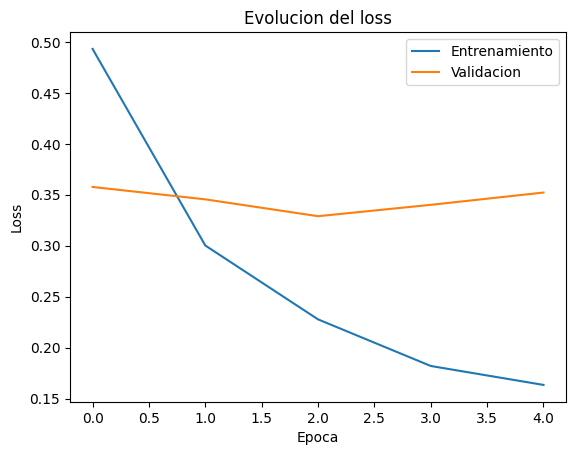

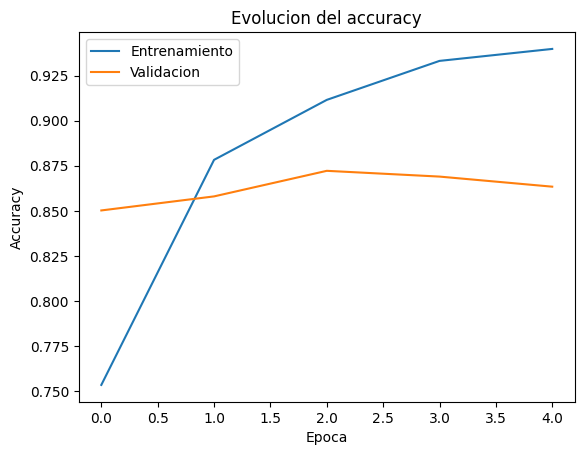

In [40]:
plt.plot(historial.history["loss"], label="Entrenamiento")
plt.plot(historial.history["val_loss"], label="Validacion")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.title("Evolucion del loss")
plt.show()

plt.plot(historial.history["accuracy"], label="Entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Validacion")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Evolucion del accuracy")
plt.show()

In [28]:
loss_tes, accuracy_test = modelo.evaluate(X_test_padded, y_test, verbose=0)
print(f"Accuracy en el test set: {accuracy_test:.2%}")

Accuracy en el test set: 85.32%


### Probando con una review propia

Escribamos una review nosotros mismos y veamos que predice el modelo. Para esto tenemos que tokenizarla "a mano", usando el mismo diccionario `indice_palabras` que usa el dataset (las palabras que no esten en el vocabulario se reemplazan por el token de "desconocido").

In [29]:
def codificar_review(texto, tam_vocabulario=tam_vocabulario_imdb):  # Convierte una review escrita en texto en una secuencia de IDs
    palabras = texto.lower().split()  # Convertimos el texto a minusculas y lo separamos en palabras
    ids = [1]  # Agregamos el token de inicio, igual que en las reviews originales de IMDB

    for palabra in palabras:  # Recorremos cada palabra de la review
        id_palabra = indice_palabras.get(palabra, -1) + 3  # Buscamos el ID de la palabra y sumamos 3 para dejar espacio para los tokens especiales
        ids.append(
            id_palabra if 0 <= id_palabra < tam_vocabulario else 2
        )  # Si la palabra esta en el vocabulario, usamos su ID; si no, usamos 2 = <desconocido>

    return ids  # Devolvemos la review convertida en una lista de IDs

In [42]:
review_propia = "this movie was absolutely wonderful, the acting was great and I loved every minute"
review_codificada = codificar_review(review_propia)
review_padded = keras.utils.pad_sequences([review_codificada], maxlen=largo_maximo)

probabilidad = modelo.predict(review_padded, verbose=0)[0, 0]
print(f"Probabilidad de que sea positiva: {probabilidad:.2%}")

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0

## Resumen

- **Tokenizacion**: convertir texto en una secuencia de unidades (tokens) con un id numerico. Programamos BPE a mano para entender como un algoritmo real construye su vocabulario, fusionando los pares mas frecuentes paso a paso.
- **Padding**: como las secuencias de texto tienen largos distintos, las rellenamos (o recortamos) para poder agruparlas en lotes.
- **Clasificacion de texto**: la misma receta de `Embedding` + capa recurrente + `Dense` que usamos para generar texto sirve, con pequeños cambios, para clasificarlo.

Los tokenizadores reales que se usan hoy en dia (en GPT, BERT, Llama, y otros) son versiones mucho mas sofisticadas y optimizadas de la misma idea que programaste a mano en este notebook.